In [ ]:
import pandas as pd

df = pd.read_csv("../data/raw/country_wise_latest.csv")

print(df.columns)
df.head()


## Limpeza dos Dados
Padronização dos nomes das colunas e verificação de inconsistências.

In [ ]:
# padronizar nomes das colunas
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("/", "_")
)

print(df.columns)
df.head()

In [ ]:
df.info()

## Criação de Métricas
Cálculo de letalidade, taxa de recuperação e taxa de casos ativos.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top10 = df.nlargest(10, "confirmed")

plt.figure(figsize=(12,6))
sns.barplot(data=top10, x="confirmed", y="country_region")
plt.title("Top 10 países com mais casos confirmados")
plt.xlabel("Casos confirmados")
plt.ylabel("País")
plt.show()

In [ ]:
df["letalidade"] = (df["deaths"] / df["confirmed"]) * 100
df["taxa_recuperacao"] = (df["recovered"] / df["confirmed"]) * 100
df["taxa_ativos"] = (df["active"] / df["confirmed"]) * 100

df[
    [
        "country_region",
        "letalidade",
        "taxa_recuperacao",
        "taxa_ativos"
    ]
].head()

In [ ]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=top10,
    x="confirmed",
    y="country_region"
)

plt.title(
    "Top 10 países com mais casos confirmados",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Casos Confirmados", fontsize=12)
plt.ylabel("País", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
top_letalidade = df.nlargest(10, "letalidade")

plt.figure(figsize=(14,7))

sns.barplot(
    data=top_letalidade,
    x="letalidade",
    y="country_region"
)

plt.title("Top 10 países com maior letalidade")
plt.xlabel("Taxa de letalidade (%)")
plt.ylabel("País")

plt.tight_layout()
plt.show()

# Análise Exploratória COVID-19
Projeto de análise comparativa da COVID-19 com foco no Brasil.

In [ ]:
#Os United States lideravam globalmente em casos confirmados, seguidos por Brazil e India. O Brasil aparece como o segundo país com maior número de casos na base analisada, evidenciando seu protagonismo no cenário pandêmico global.#

In [ ]:
brasil = df[df["country_region"] == "Brazil"]

brasil

In [ ]:
media_mundial = df[
    [
        "confirmed",
        "deaths",
        "recovered",
        "letalidade",
        "taxa_recuperacao"
    ]
].mean()

media_mundial

## Brasil vs Mundo
Comparação dos principais indicadores do Brasil com a média global.

In [ ]:
comparacao = pd.DataFrame({
    "Brasil": [
        brasil["confirmed"].values[0],
        brasil["deaths"].values[0],
        brasil["recovered"].values[0],
        brasil["letalidade"].values[0],
        brasil["taxa_recuperacao"].values[0]
    ],
    "Média Mundial": media_mundial.values
},
index=[
    "Casos",
    "Mortes",
    "Recuperados",
    "Letalidade %",
    "Recuperação %"
])

comparacao

In [ ]:
comparacao.plot(
    kind="bar",
    figsize=(14,7)
)

plt.title("Brasil vs Média Mundial")
plt.ylabel("Valores")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
regioes = df.groupby("who_region")[
    [
        "confirmed",
        "deaths",
        "recovered",
        "letalidade",
        "taxa_recuperacao"
    ]
].mean()

regioes

In [ ]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=df,
    x="who_region",
    y="letalidade"
)

plt.title("Taxa média de letalidade por região OMS")
plt.xlabel("Região")
plt.ylabel("Letalidade (%)")

plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
ranking_brasil = (
    df.sort_values("confirmed", ascending=False)
      .reset_index(drop=True)
)

posicao = ranking_brasil[
    ranking_brasil["country_region"] == "Brazil"
].index[0] + 1

print(f"Brasil está na posição {posicao} em casos confirmados.")

## Regiões OMS

In [ ]:
regioes = df.groupby("who_region")[
    [
        "confirmed",
        "deaths",
        "recovered",
        "letalidade",
        "taxa_recuperacao"
    ]
].mean()

regioes

In [ ]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=df,
    x="who_region",
    y="letalidade"
)

plt.title("Taxa média de letalidade por região OMS")
plt.xlabel("Região")
plt.ylabel("Letalidade (%)")

plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Observação

A região da Europa apresentou a maior taxa média de letalidade entre as regiões analisadas pela OMS.

Esse resultado sugere um impacto proporcionalmente maior das mortes em relação aos casos confirmados nessa região, podendo refletir fatores como perfil demográfico da população, momento de pico da pandemia e capacidade dos sistemas de saúde durante períodos críticos.

## Crescimento Semanal dos Casos
Análise dos países com maior aceleração recente de casos confirmados.

In [ ]:
crescimento = df.nlargest(10, "1_week_%_increase")

crescimento[
    [
        "country_region",
        "confirmed",
        "1_week_change",
        "1_week_%_increase"
    ]
]

In [ ]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=crescimento,
    x="1_week_%_increase",
    y="country_region"
)

plt.title("Top 10 países com maior crescimento semanal (%)")
plt.xlabel("Crescimento semanal (%)")
plt.ylabel("País")

plt.tight_layout()
plt.show()

In [ ]:
df.to_csv("../data/processed/covid_tratado.csv", index=False)

print("Dataset salvo com sucesso.")

## Brasil vs Top 10 Países Mais Afetados

Comparação do Brasil com os países mais impactados em número de casos confirmados.

In [ ]:
top10 = df.nlargest(10, "confirmed")

top10[
    [
        "country_region",
        "confirmed",
        "deaths",
        "letalidade",
        "taxa_recuperacao"
    ]
]

In [ ]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=top10,
    x="country_region",
    y="confirmed"
)

plt.title("Brasil comparado ao Top 10 em Casos Confirmados")
plt.xlabel("País")
plt.ylabel("Casos Confirmados")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Insight

Na comparação com os 10 países mais afetados pela COVID-19, o :contentReference[oaicite:0]{index=0} ocupa a **2ª posição em número de casos confirmados**, ficando atrás apenas dos :contentReference[oaicite:1]{index=1} e à frente da :contentReference[oaicite:2]{index=2}.

Esse resultado evidencia a magnitude do impacto da pandemia no Brasil dentro do cenário global.

## Evolução Temporal da COVID-19

Análise da evolução dos casos confirmados ao longo do tempo, com foco no Brasil e no cenário global.

In [ ]:
df2 = pd.read_csv("../data/raw/covid_19_clean_complete.csv")

print(df2.columns)
df2.head()

In [40]:
df2.columns = (
    df2.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("/", "_")
)

print(df2.columns)

Index(['province_state', 'country_region', 'lat', 'long', 'date', 'confirmed',
       'deaths', 'recovered', 'active', 'who_region'],
      dtype='str')


In [41]:
df2["date"] = pd.to_datetime(df2["date"])

df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   province_state  14664 non-null  str           
 1   country_region  49068 non-null  str           
 2   lat             49068 non-null  float64       
 3   long            49068 non-null  float64       
 4   date            49068 non-null  datetime64[us]
 5   confirmed       49068 non-null  int64         
 6   deaths          49068 non-null  int64         
 7   recovered       49068 non-null  int64         
 8   active          49068 non-null  int64         
 9   who_region      49068 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(4), str(3)
memory usage: 3.7 MB


In [42]:
brasil_tempo = (
    df2[df2["country_region"] == "Brazil"]
    .groupby("date")["confirmed"]
    .sum()
)

brasil_tempo.head()

date
2020-01-22    0
2020-01-23    0
2020-01-24    0
2020-01-25    0
2020-01-26    0
Name: confirmed, dtype: int64

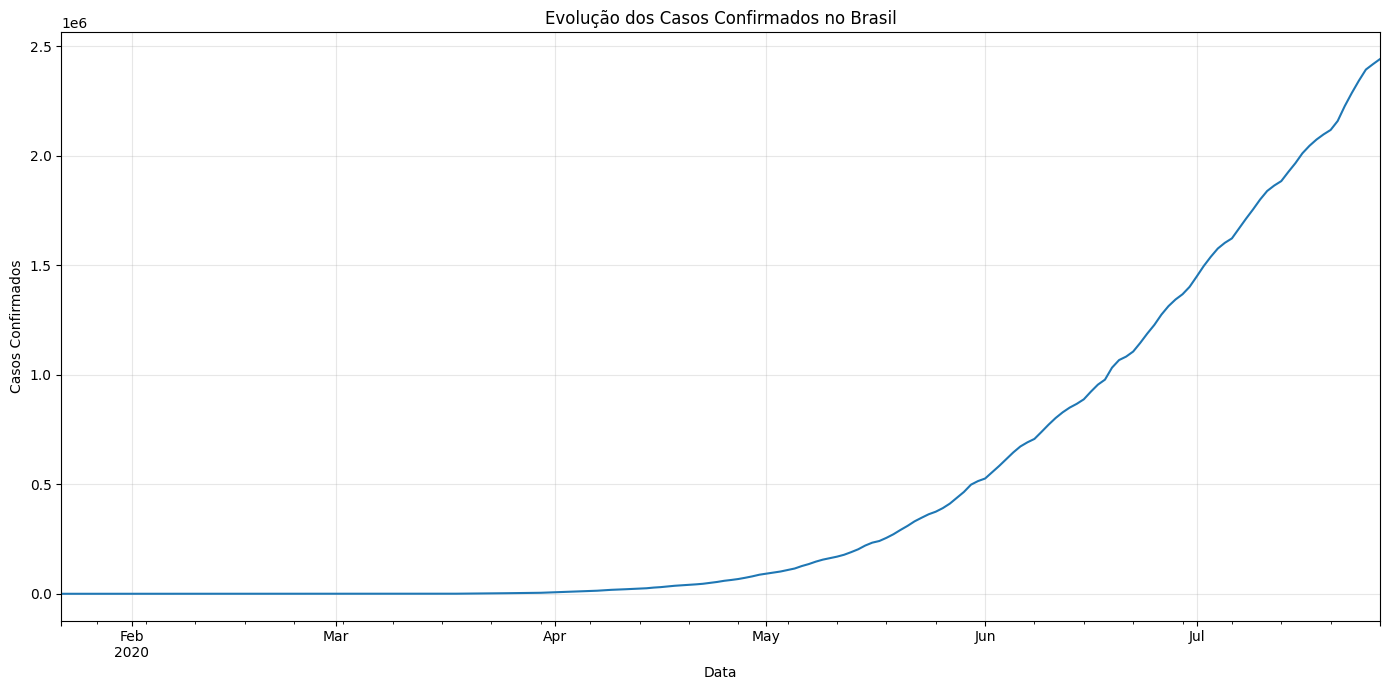

In [43]:
plt.figure(figsize=(14,7))

brasil_tempo.plot()

plt.title("Evolução dos Casos Confirmados no Brasil")
plt.xlabel("Data")
plt.ylabel("Casos Confirmados")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Insight

A curva temporal do :contentReference[oaicite:1]{index=1} evidencia crescimento acelerado dos casos confirmados ao longo do período analisado, com comportamento típico de expansão exponencial durante fases críticas da pandemia.

In [44]:
mundo_tempo = (
    df2.groupby("date")["confirmed"]
    .sum()
)

mundo_tempo.head()

date
2020-01-22     555
2020-01-23     654
2020-01-24     941
2020-01-25    1434
2020-01-26    2118
Name: confirmed, dtype: int64

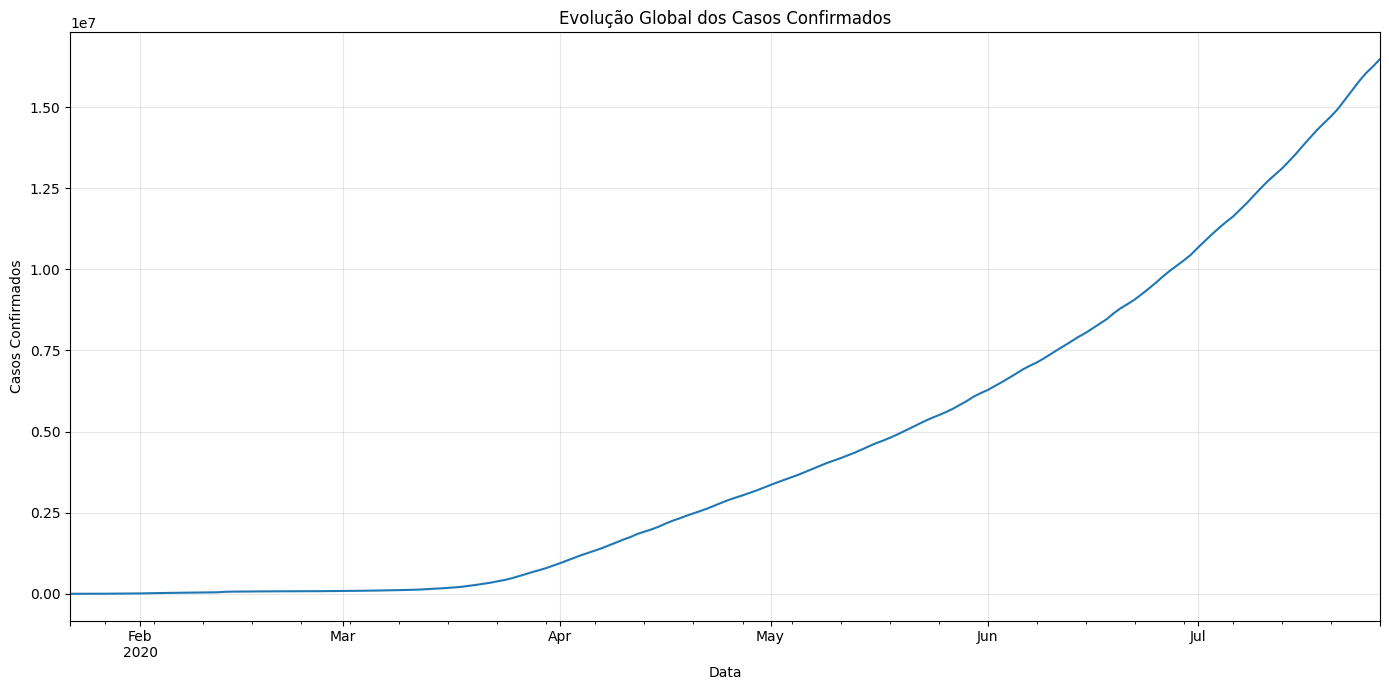

In [45]:
plt.figure(figsize=(14,7))

mundo_tempo.plot()

plt.title("Evolução Global dos Casos Confirmados")
plt.xlabel("Data")
plt.ylabel("Casos Confirmados")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

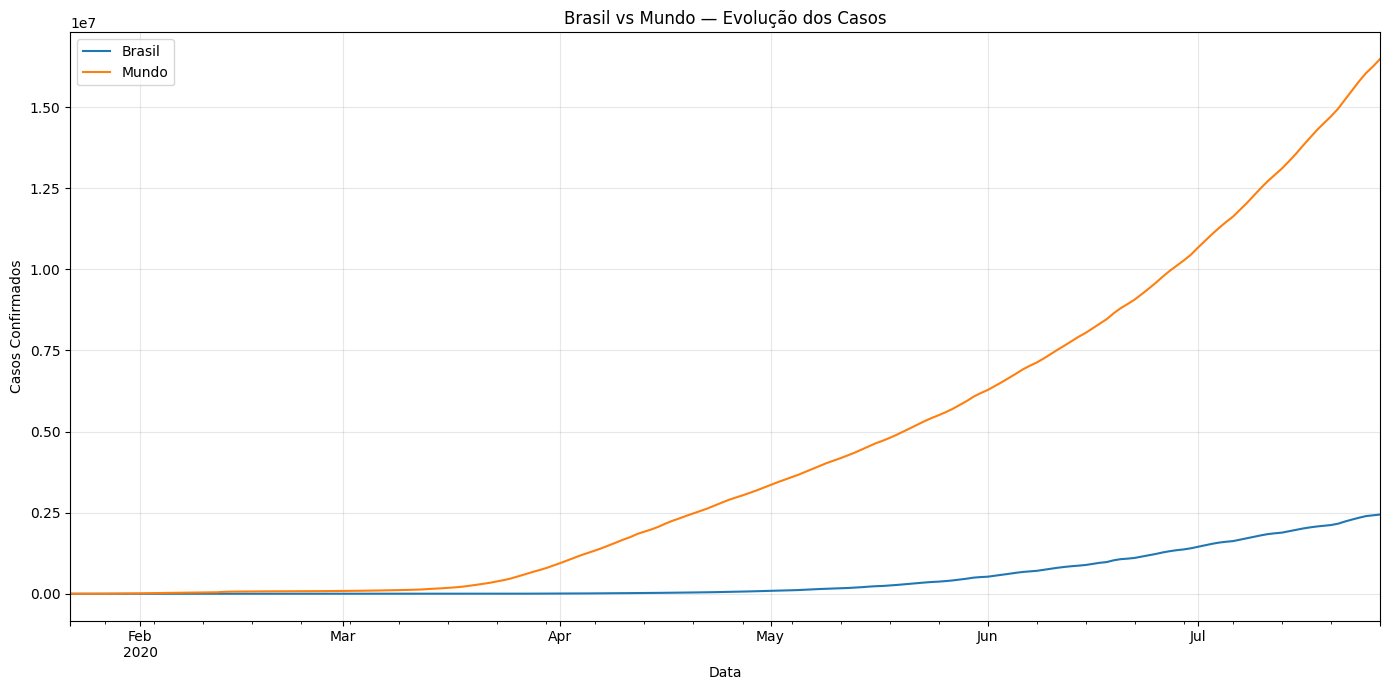

In [46]:
plt.figure(figsize=(14,7))

brasil_tempo.plot(label="Brasil")
mundo_tempo.plot(label="Mundo")

plt.title("Brasil vs Mundo — Evolução dos Casos")
plt.xlabel("Data")
plt.ylabel("Casos Confirmados")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Insight

Ao comparar o Brasil com o cenário global, observa-se que a curva nacional acompanha a tendência mundial de crescimento acelerado, reforçando a relevância do país no contexto internacional da pandemia.

## Crescimento Diário de Casos

Análise da variação diária de novos casos confirmados no Brasil e no cenário global.

In [47]:
novos_brasil = brasil_tempo.diff()

novos_brasil.head(10)

date
2020-01-22    NaN
2020-01-23    0.0
2020-01-24    0.0
2020-01-25    0.0
2020-01-26    0.0
2020-01-27    0.0
2020-01-28    0.0
2020-01-29    0.0
2020-01-30    0.0
2020-01-31    0.0
Name: confirmed, dtype: float64

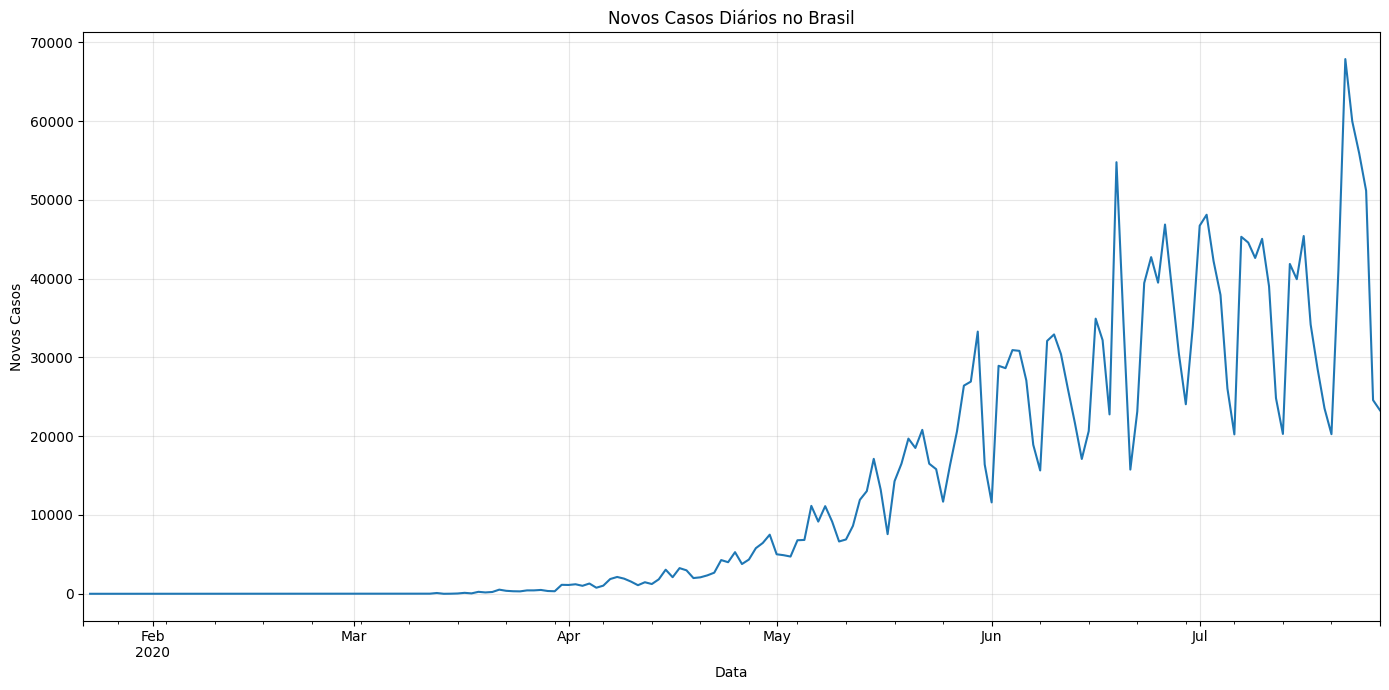

In [48]:
plt.figure(figsize=(14,7))

novos_brasil.plot()

plt.title("Novos Casos Diários no Brasil")
plt.xlabel("Data")
plt.ylabel("Novos Casos")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

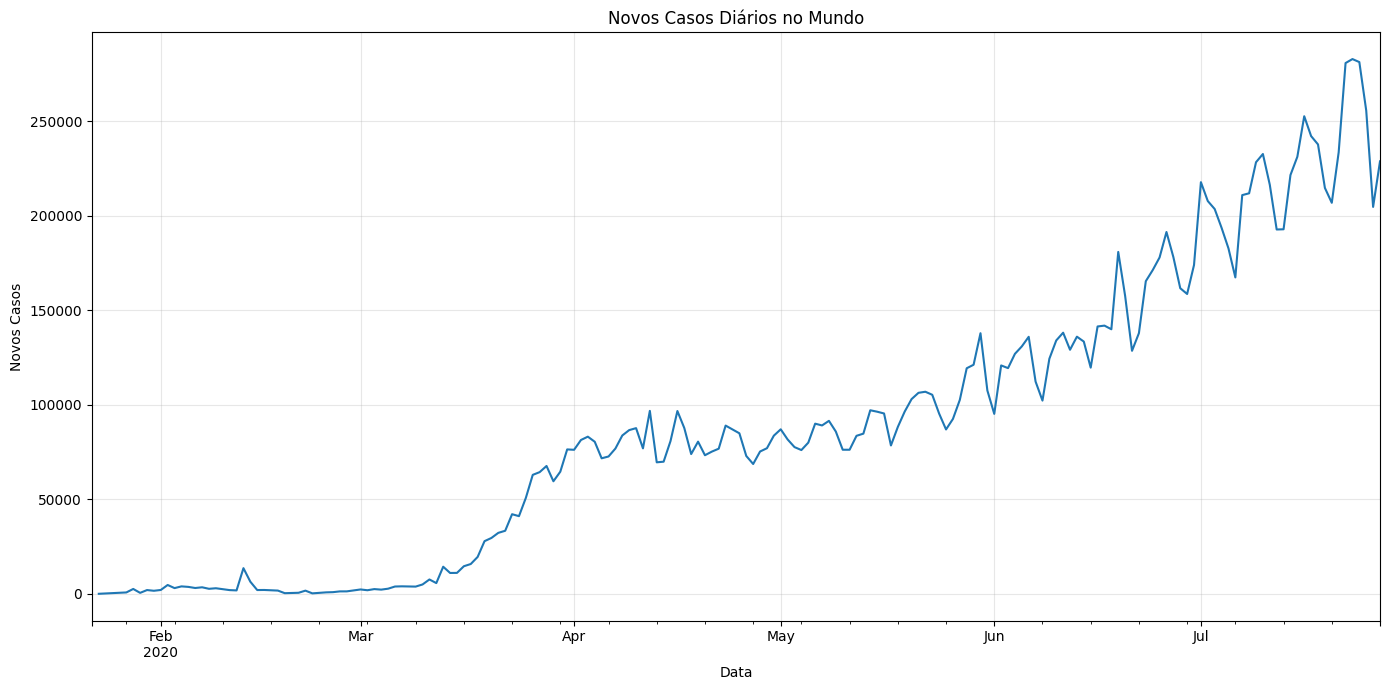

In [49]:
novos_mundo = mundo_tempo.diff()

plt.figure(figsize=(14,7))

novos_mundo.plot()

plt.title("Novos Casos Diários no Mundo")
plt.xlabel("Data")
plt.ylabel("Novos Casos")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Insight

A análise dos novos casos diários permite identificar períodos de aceleração e desaceleração da pandemia, complementando a leitura dos dados acumulados e oferecendo melhor percepção sobre o ritmo de disseminação da COVID-19.

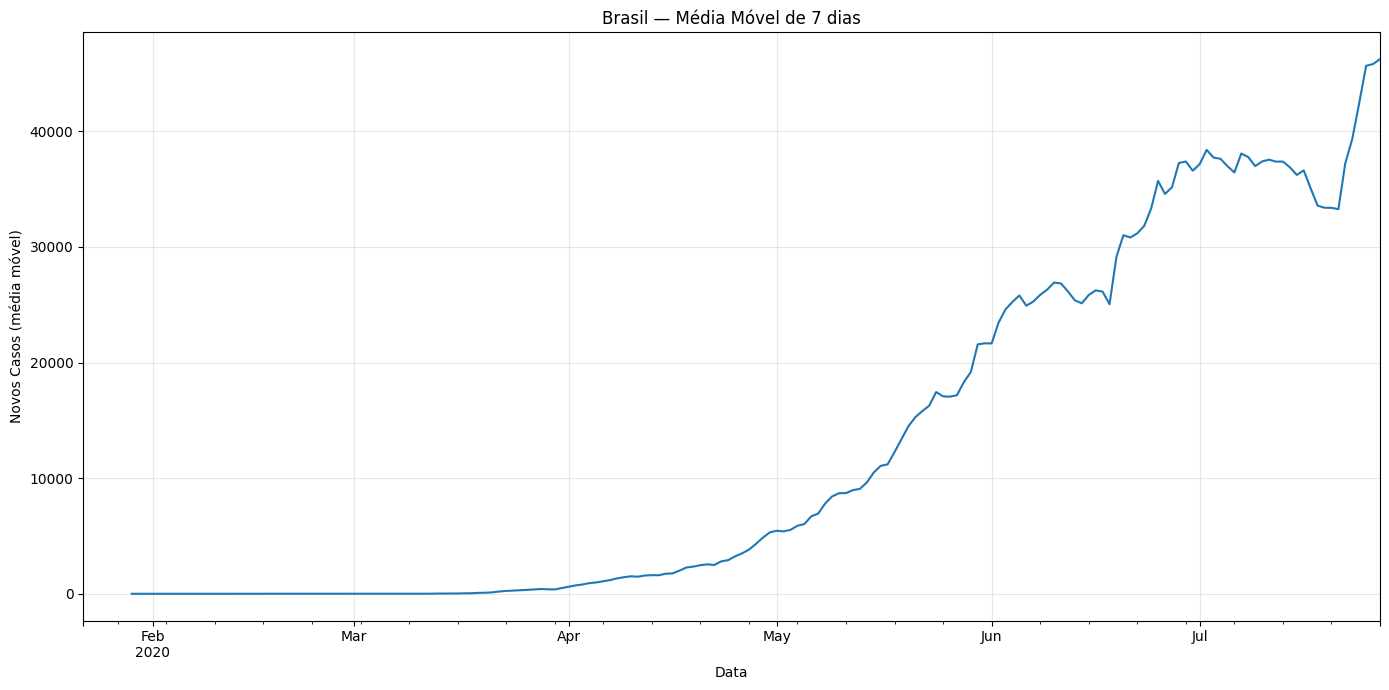

In [50]:
media_movel_brasil = novos_brasil.rolling(7).mean()

plt.figure(figsize=(14,7))

media_movel_brasil.plot()

plt.title("Brasil — Média Móvel de 7 dias")
plt.xlabel("Data")
plt.ylabel("Novos Casos (média móvel)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Insight

A utilização da média móvel de 7 dias reduz oscilações pontuais dos registros diários e evidencia com maior clareza a tendência de crescimento ou desaceleração dos casos ao longo do tempo.

### Insight

A média móvel de 7 dias no Brasil apresenta comportamento oscilatório ao longo do período analisado.

Observa-se inicialmente um crescimento consistente, seguido por momentos de desaceleração, nova aceleração, uma queda mais acentuada e, por fim, retomada da tendência de alta.

Esse comportamento indica diferentes fases da pandemia, com períodos alternados de expansão e redução no ritmo de novos casos confirmados.

In [51]:
df.to_csv("../data/processed/covid_tratado.csv", index=False)
df2.to_csv("../data/processed/covid_temporal_tratado.csv", index=False)

print("Arquivos salvos com sucesso.")

Arquivos salvos com sucesso.
